In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

## 1. PINN Architecture Definition
Definition of the standard Neural Network (Multi-Layer Perceptron) to approximate the solution $u(t,x)$.

In [2]:
class PinnHeatEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        return self.couche_sortie(x)

## 2. Sampling and Collocation Points Generation
Functions to generate collocation points (in the domain), initial points ($t=0$), and boundary points ($x=0$ and $x=1$).

In [3]:
t_min, t_max = 0.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    t_colloc = torch.rand(n_pde, 1) * (t_max - t_min) + t_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return t_colloc.float(), x_colloc.float()


def generer_points_initiaux(n_iv):
    t_init = torch.zeros(n_iv, 1)
    x_init = torch.rand(n_iv, 1) * (x_max - x_min) + x_min
    return t_init.float(), x_init.float()


def generer_points_bords(n_bords):
    t_bord = torch.rand(n_bords, 1) * (t_max - t_min) + t_min
    x_gauche = torch.ones(n_bords // 2, 1) * x_min
    x_droite = torch.ones(n_bords // 2, 1) * x_max
    x_bord = torch.cat([x_gauche, x_droite], dim=0)
    return t_bord.float(), x_bord.float()

## 3. Loss Functions Definition
Grouping of loss calculation functions for initial conditions (IV), boundary conditions (BC), and the PDE residual (CLP).

In [4]:
def calc_iv_loss(model, t_init, x_init, u_exact_init):
    u_pred = model(torch.cat([t_init, x_init], dim=1))
    return torch.mean((u_pred - u_exact_init) ** 2)


def calc_bc_loss(model, t_bord, x_bord, u_exact_bord):
    u_pred = model(torch.cat([t_bord, x_bord], dim=1))
    return torch.mean((u_pred - u_exact_bord) ** 2)


def calc_clp_loss(model, t_colloc, x_colloc, alpha):
    t_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    u_pred = model(torch.cat([t_colloc, x_colloc], dim=1))

    u_t = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_x = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]

    residu = u_t - alpha * u_xx
    return torch.mean(residu ** 2)

## 4. Hardware (Device), Model, and Optimizer Initialization
Hardware detection, model creation, and optimizer definition.

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

alpha = 0.0005

modele = PinnHeatEq().to(device)
optimizer = optim.Adam(modele.parameters(), lr=0.001)

t_colloc, x_colloc = generer_points_collocation(12000)
t_init, x_init = generer_points_initiaux(1000)
t_bord, x_bord = generer_points_bords(1000)

u_exact_init = torch.sin(2 * torch.pi * x_init)
u_exact_bord = torch.zeros_like(x_bord)

t_colloc, x_colloc = t_colloc.to(device), x_colloc.to(device)
t_init, x_init = t_init.to(device), x_init.to(device)
t_bord, x_bord = t_bord.to(device), x_bord.to(device)
u_exact_init = u_exact_init.to(device)
u_exact_bord = u_exact_bord.to(device)

mps


## 5. Model Training
Training phase of the PINN model using the defined optimizers (Adam and/or L-BFGS).

In [6]:
epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()

    loss_iv = calc_iv_loss(modele, t_init, x_init, u_exact_init)
    loss_bc = calc_bc_loss(modele, t_bord, x_bord, u_exact_bord)
    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, alpha)

    loss_totale = 300 * loss_iv + 100 * loss_bc + loss_clp
    loss_totale.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:05d} | "
              f"Loss totale: {loss_totale.item():.2e} | "
              f"CLP: {loss_clp.item():.2e} | "
              f"BC: {loss_bc.item():.2e} | "
              f"IV: {loss_iv.item():.2e}")


def closure():
    optimizer.zero_grad()
    
    loss_iv = calc_iv_loss(modele, t_init, x_init, u_exact_init)
    loss_bc = calc_bc_loss(modele, t_bord, x_bord, u_exact_bord)
    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, alpha)

    loss_totale = 300 * loss_iv + 100 * loss_bc + loss_clp
    loss_totale.backward()
    return loss_totale

lbfgs_epochs = 500
optimizer = optim.LBFGS(modele.parameters(), line_search_fn="strong_wolfe",max_iter = 20)
for epoch in range(lbfgs_epochs):
    loss = optimizer.step(closure)
    if epoch % 100 == 0:
        print(f"Epoque LBFGS {epoch:05d} | "
              f"Loss totale: {loss.item():.2e}")


Epoque 00000 | Loss totale: 1.45e+02 | CLP: 1.38e-04 | BC: 2.19e-02 | IV: 4.77e-01


Epoque 00100 | Loss totale: 7.03e+01 | CLP: 2.89e-01 | BC: 1.08e-01 | IV: 1.97e-01


Epoque 00200 | Loss totale: 1.67e+01 | CLP: 9.20e-01 | BC: 1.90e-02 | IV: 4.61e-02


Epoque 00300 | Loss totale: 9.99e-01 | CLP: 6.00e-01 | BC: 5.81e-04 | IV: 1.14e-03


Epoque 00400 | Loss totale: 4.63e-01 | CLP: 3.93e-01 | BC: 1.53e-04 | IV: 1.80e-04


...

Epoque LBFGS 00000 | Loss totale: 3.84e-02


Epoque LBFGS 00100 | Loss totale: 2.94e-05


Epoque LBFGS 00200 | Loss totale: 2.94e-05


Epoque LBFGS 00300 | Loss totale: 2.94e-05


Epoque LBFGS 00400 | Loss totale: 2.94e-05


## 6. Visualizing the Results
Comparison of the solution learned by the PINN with the exact analytical solution of the heat equation.

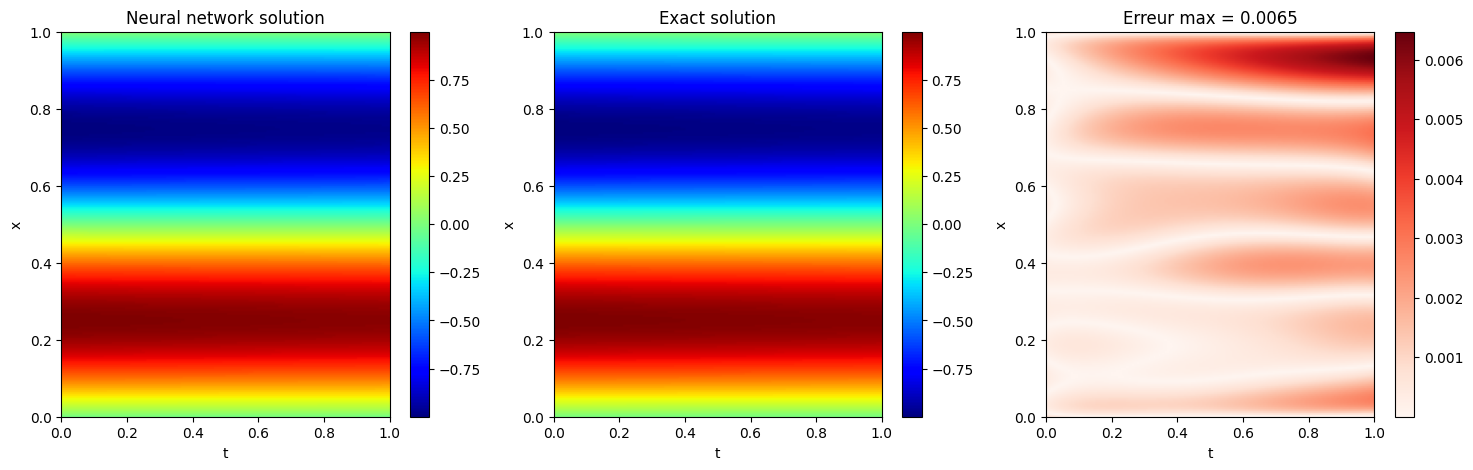

In [7]:
import sys; sys.path.append("..")
import numpy as np                                                                                                    
from pinnplot import plot_solution                        

u_exact = lambda t, x: np.sin(2*np.pi*x) * np.exp(-(2*np.pi)**2 * alpha * t)

plot_solution(modele, u_exact)           
